# TRABAJO FINAL MODULO 6
# ALUMNO : CÉSAR MAYTA


## RED NEURONAL PARA TELCO CHURN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/telco_data_transformed.csv')
df

,gender,partner,dependents,phone_service,paperless_billing,churn,payment_transfer,payment_creditcard,payment_check,payment_mail,...,tech_support_no,tech_support_noservice,tech_support_yes,internet_dsl,internet_fiber,internet_no,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,24.0,84.80,1990.50
7039,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,72.0,103.20,7362.90
7040,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,11.0,29.60,346.45
7041,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,74.40,306.60


In [4]:
df.dropna(inplace=True)
df

,gender,partner,dependents,phone_service,paperless_billing,churn,payment_transfer,payment_creditcard,payment_check,payment_mail,...,tech_support_no,tech_support_noservice,tech_support_yes,internet_dsl,internet_fiber,internet_no,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,24.0,84.80,1990.50
7039,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,72.0,103.20,7362.90
7040,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,11.0,29.60,346.45
7041,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,74.40,306.60


In [5]:
df['churn'].value_counts()

,count
churn,
0.0,5163
1.0,1869


In [6]:
corr_matrix = df.corr()
corr_churn = corr_matrix[['churn']].sort_values(by='churn',ascending=False)
corr_churn

,churn
churn,1.000000
contract_month,0.404565
security_no,0.342235
tech_support_no,0.336877
internet_fiber,0.307463
payment_check,0.301455
backup_no,0.267595
device_protection_no,0.252056
monthly_charges,0.192858
paperless_billing,0.191454


In [7]:
cols = corr_churn.index.tolist()
cols.remove('churn')
cols

['contract_month',
 'security_no',
 'tech_support_no',
 'internet_fiber',
 'payment_check',
 'backup_no',
 'device_protection_no',
 'monthly_charges',
 'paperless_billing',
 'senior_citizen',
 'movies_no',
 'tv_no',
 'tv_yes',
 'movies_yes',
 'multiple_lines_yes',
 'phone_service',
 'gender',
 'multiple_lines_noservice',
 'multiple_lines_no',
 'device_protection_yes',
 'backup_yes',
 'payment_mail',
 'payment_transfer',
 'internet_dsl',
 'payment_creditcard',
 'partner',
 'dependents',
 'tech_support_yes',
 'security_yes',
 'contract_year',
 'total_charges',
 'tv__no internet service',
 'tech_support_noservice',
 'backup_noservice',
 'security_noservice',
 'device_protection_noservice',
 'internet_no',
 'movies_noservice',
 'contract_twoyears',
 'tenure']

In [8]:
df.shape

(7032, 41)

In [9]:
X = df[cols].values
y = df['churn'].values.reshape(-1,1)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

## BALANCEO DE VARIABLE DEPENDIENTE Y

In [15]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)


# CREAMOS UNA RED NEURONAL DE CLASIFICACIÓN BINARIA

## 1 - IMPORTAMOS LIBRERIAS

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
from tensorflow.keras.layers import Dropout

## 2 - CREAMOS LA RED NEURONAL

In [17]:
red = Sequential()
inputs = Input(shape=(X.shape[1],))
entrada = Dense(units=500,activation='relu')
oculta1 = Dense(units=500,activation='relu')
oculta2 = Dense(units=500,activation='relu')
salida = Dense(units=1,activation='sigmoid')

red.add(inputs)
red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red

<Sequential name=sequential, built=True>

## 3 - CONFIGURAMOS LA RED

In [18]:
red.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 4 - ENTRENAMOS LA RED

In [19]:
model1 = red.fit(X_train,y_train,epochs=2,batch_size=128,validation_data=(X_test,y_test))

Epoch 1/2
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7280 - loss: 0.5767 - val_accuracy: 0.7370 - val_loss: 0.5238
Epoch 2/2
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7650 - loss: 0.4884 - val_accuracy: 0.7413 - val_loss: 0.5260


## 5 -  VALIDAMOS AL RED

In [20]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
el accuracy es 0.7412935323383084


## 6 -  MATRIZ DE CONFUSIÓN

<Figure size 1100x1100 with 0 Axes>

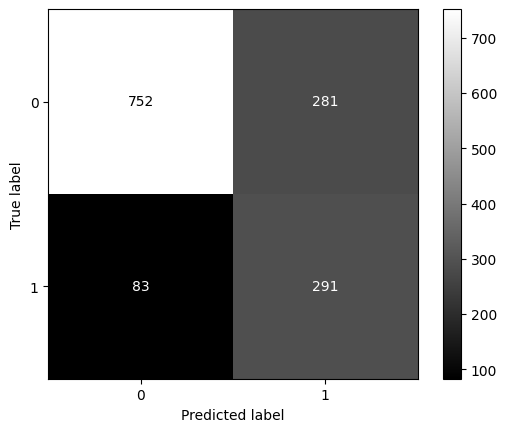

In [21]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()

## 7 - VERIFICAMOS OVERFITTING

In [22]:
def plot_overfitting(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(epochs, history.history['val_loss'], label='Pérdida de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.title('Pérdida en entrenamiento vs validación')

    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(epochs, history.history['val_accuracy'], label='Precisión de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.title('Precisión en entrenamiento vs validación')

    plt.show()

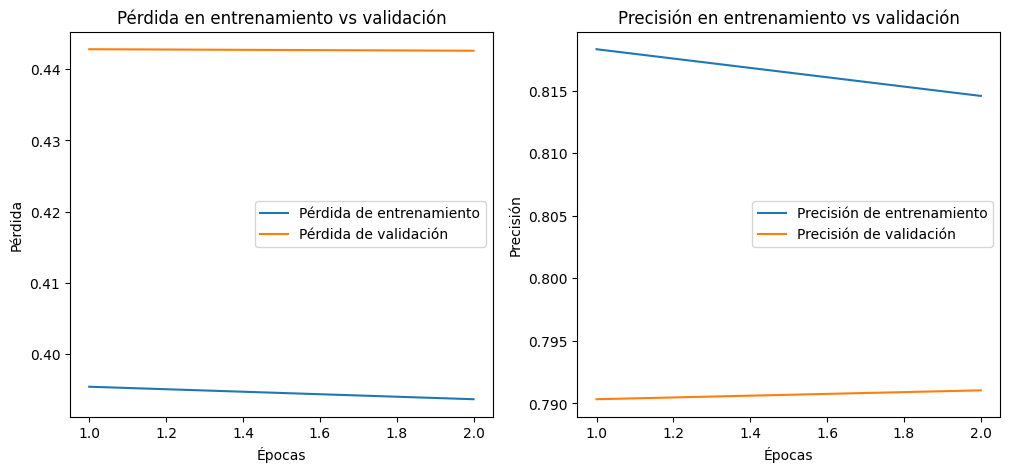

In [25]:
plot_overfitting(model1)